# Beispieldaten erzeugen

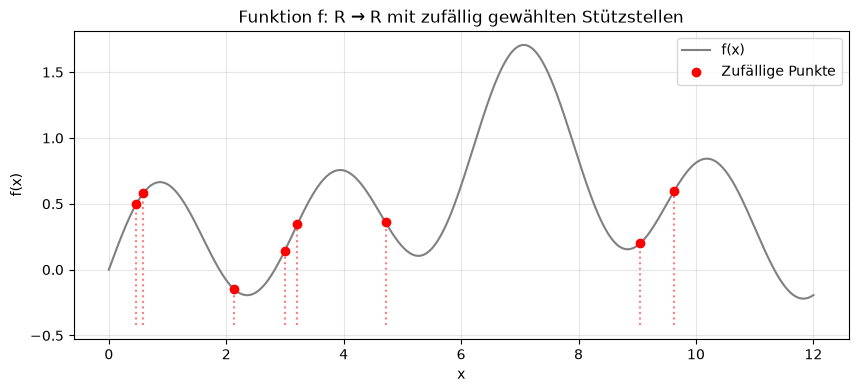

,x,f(x)
0,0.465396,0.497095
1,0.589111,0.582252
2,2.137161,-0.149564
3,2.995189,0.142361
4,3.212720,0.346084
5,4.712502,0.358408
6,9.054953,0.201481
7,9.626169,0.595340


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Funktion f: R -> R (Überlagerung von Sinus-Schwingungen und einer Gauß-Glocke)
def f(x):
    return 0.5 * np.sin(2 * x) + 0.3 * np.sin(0.7 * x) + 1.5 * np.exp(-((x - 7) ** 2) / 4)

# Funktion in einer Variablen ablegen (hier eine Referenz auf die Funktion selbst)
funktion = f

# 2) Plot der Funktion
x_plot = np.linspace(0, 12, 500)
y_plot = funktion(x_plot)

# 3) Zufällige x-Punkte und zugehörige Funktionswerte
N = 8
rng = np.random.default_rng()
x_samples = np.sort(rng.uniform(0, 12, size=N))
y_samples = funktion(x_samples)

df = pd.DataFrame({"x": x_samples, "f(x)": y_samples})

plt.figure(figsize=(10, 4))
plt.plot(x_plot, y_plot, color="gray", label="f(x)")
plt.scatter(x_samples, y_samples, color="red", zorder=3, label="Zufällige Punkte")
plt.vlines(x_samples, ymin=y_plot.min() - 0.2, ymax=y_samples,
           colors="red", linestyles="dotted", alpha=0.5)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Funktion f: R → R mit zufällig gewählten Stützstellen")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

df

In [12]:
f(3)

np.float64(0.1467285192283005)

# Berechnungsgraphen visualisieren (mit Matplotlib direkt)

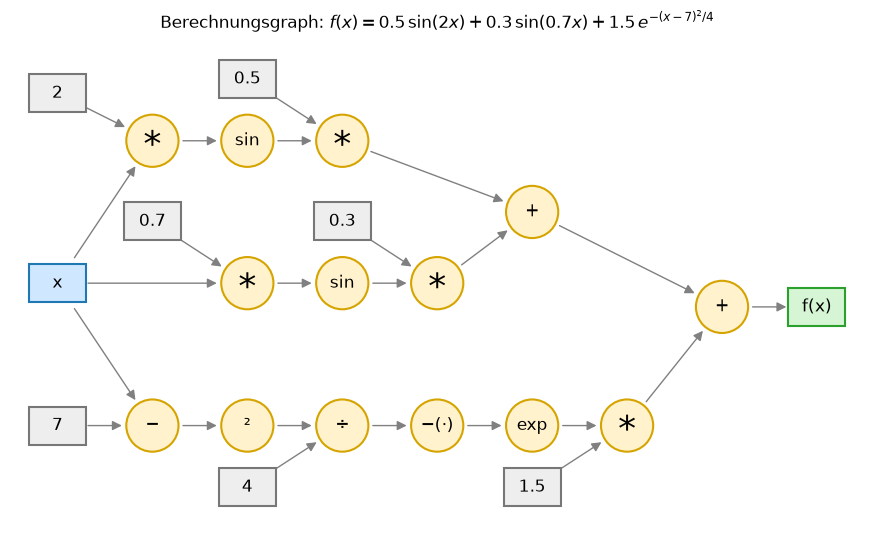

In [9]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

# Knoten: Name -> (x-Position, y-Position, Beschriftung, Typ)
nodes = {
    "x":    (0, 3, "x", "input"),
    # Zweig A: 0.5 * sin(2x)
    "c2":   (0, 7, "2", "const"),
    "mA":   (2, 6, "*", "op"),
    "sA":   (4, 6, "sin", "op"),
    "c05":  (4, 7.3, "0.5", "const"),
    "wA":   (6, 6, "*", "op"),
    # Zweig B: 0.3 * sin(0.7x)
    "c07":  (2, 4.3, "0.7", "const"),
    "mB":   (4, 3, "*", "op"),
    "sB":   (6, 3, "sin", "op"),
    "c03":  (6, 4.3, "0.3", "const"),
    "wB":   (8, 3, "*", "op"),
    # Zweig C: 1.5 * exp(-(x-7)^2 / 4)
    "c7":   (0, 0, "7", "const"),
    "sub":  (2, 0, "−", "op"),
    "sq":   (4, 0, "²", "op"),
    "c4":   (4, -1.3, "4", "const"),
    "div":  (6, 0, "÷", "op"),
    "neg":  (8, 0, "−(·)", "op"),
    "exp":  (10, 0, "exp", "op"),
    "c15":  (10, -1.3, "1.5", "const"),
    "wC":   (12, 0, "*", "op"),
    # Summen
    "add1": (10, 4.5, "+", "op"),
    "add2": (14, 2.5, "+", "op"),
    "out":  (16, 2.5, "f(x)", "output"),
}
edges = [
    ("x", "mA"), ("c2", "mA"), ("mA", "sA"), ("sA", "wA"), ("c05", "wA"),
    ("x", "mB"), ("c07", "mB"), ("mB", "sB"), ("sB", "wB"), ("c03", "wB"),
    ("x", "sub"), ("c7", "sub"), ("sub", "sq"), ("sq", "div"), ("c4", "div"),
    ("div", "neg"), ("neg", "exp"), ("exp", "wC"), ("c15", "wC"),
    ("wA", "add1"), ("wB", "add1"), ("add1", "add2"), ("wC", "add2"),
    ("add2", "out"),
]
style = {
    "input":  dict(fc="#cfe8ff", ec="#1f77b4"),
    "const":  dict(fc="#eeeeee", ec="#777777"),
    "op":     dict(fc="#fff2cc", ec="#d6a400"),
    "output": dict(fc="#d5f5d5", ec="#2ca02c"),
}

fig, ax = plt.subplots(figsize=(14, 5.5))
r = 0.55
for a, b in edges:
    xa, ya = nodes[a][:2]; xb, yb = nodes[b][:2]
    ax.add_patch(FancyArrowPatch((xa, ya), (xb, yb), arrowstyle="-|>", mutation_scale=14,
                                 color="gray", shrinkA=22, shrinkB=22, zorder=1))
for x, y, label, kind in nodes.values():
    if kind == "op":
        ax.add_patch(plt.Circle((x, y), r, lw=1.5, zorder=2, **style[kind]))
    else:
        ax.add_patch(plt.Rectangle((x - 0.6, y - 0.4), 1.2, 0.8, lw=1.5, zorder=2, **style[kind]))
    if label == "*":
        # Der Stern sitzt in der Schrift hoch, daher etwas nach unten versetzen
        ax.text(x, y - 0.12, label, ha="center", va="center", fontsize=26, zorder=3)
    else:
        ax.text(x, y, label, ha="center", va="center", fontsize=12, zorder=3)

ax.set_xlim(-1, 17); ax.set_ylim(-2.2, 8.2)
ax.set_aspect("equal"); ax.axis("off")
ax.set_title(r"Berechnungsgraph: $f(x)=0.5\,\sin(2x)+0.3\,\sin(0.7x)+1.5\,e^{-(x-7)^2/4}$")
plt.tight_layout()
plt.show()

# Berechnungsgraph visualisieren (mit graphviz)

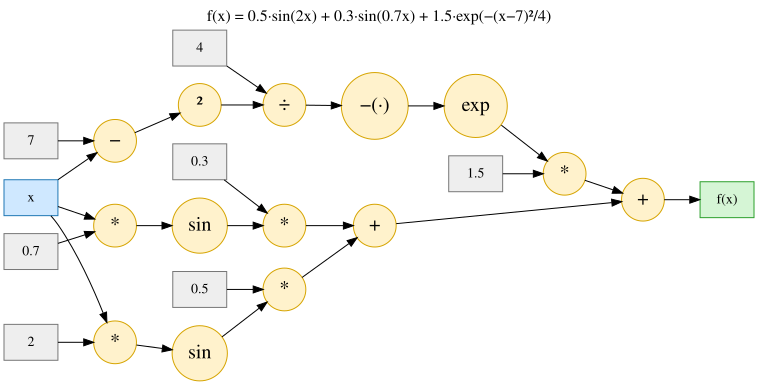

In [10]:
# Einmalig: pip install graphviz  (zusätzlich muss das Programm "dot" installiert sein,
# z.B. per "sudo apt install graphviz" bzw. "conda install graphviz")
from graphviz import Digraph

g = Digraph("f", graph_attr={"rankdir": "LR",
                             "label": "f(x) = 0.5·sin(2x) + 0.3·sin(0.7x) + 1.5·exp(−(x−7)²/4)",
                             "labelloc": "t", "fontsize": "16"})

inp   = dict(shape="box",    style="filled", fillcolor="#cfe8ff", color="#1f77b4")
const = dict(shape="box",    style="filled", fillcolor="#eeeeee", color="#777777")
op    = dict(shape="circle", style="filled", fillcolor="#fff2cc", color="#d6a400", fontsize="20")
out   = dict(shape="box",    style="filled", fillcolor="#d5f5d5", color="#2ca02c")

g.node("x", "x", **inp)
g.node("out", "f(x)", **out)
for n, l in {"c2": "2", "c05": "0.5", "c07": "0.7", "c03": "0.3",
             "c7": "7", "c4": "4", "c15": "1.5"}.items():
    g.node(n, l, **const)
for n, l in {"mA": "*", "sA": "sin", "wA": "*", "mB": "*", "sB": "sin", "wB": "*",
             "sub": "−", "sq": "²", "div": "÷", "neg": "−(·)", "exp": "exp", "wC": "*",
             "add1": "+", "add2": "+"}.items():
    g.node(n, l, **op)

for a, b in [("x", "mA"), ("c2", "mA"), ("mA", "sA"), ("sA", "wA"), ("c05", "wA"),
             ("x", "mB"), ("c07", "mB"), ("mB", "sB"), ("sB", "wB"), ("c03", "wB"),
             ("x", "sub"), ("c7", "sub"), ("sub", "sq"), ("sq", "div"), ("c4", "div"),
             ("div", "neg"), ("neg", "exp"), ("exp", "wC"), ("c15", "wC"),
             ("wA", "add1"), ("wB", "add1"), ("add1", "add2"), ("wC", "add2"),
             ("add2", "out")]:
    g.edge(a, b)

g  # wird in Jupyter direkt als Grafik angezeigt

# Die Funktion als PyTorch Berechnungsgraphen darstellen

tensor(0.1467, grad_fn=<AddBackward0>)


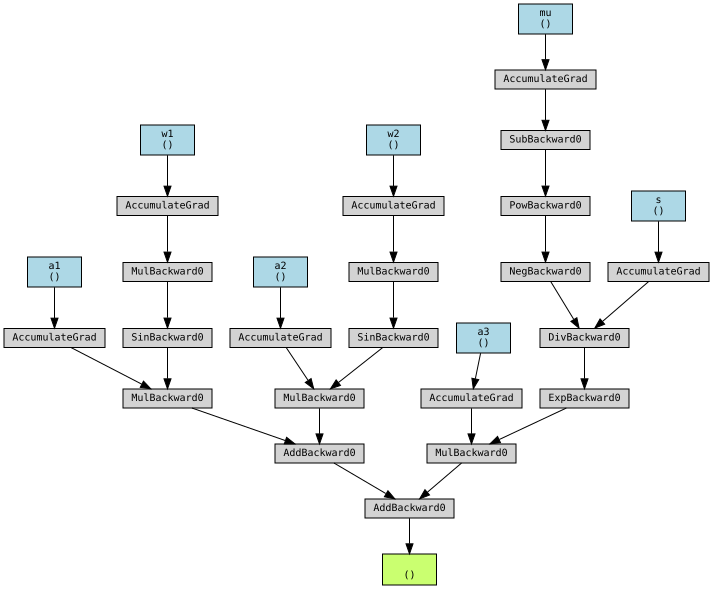

In [ ]:
# Einmalig: pip install torch torchviz  (plus das Programm "dot" von Graphviz)
import torch
import torch.nn as nn
from torchviz import make_dot


class Funktion(nn.Module):
    """f(x) = a1 *   sin(w1*x)+ a2  *    sin(w2  * x) + a3   *   exp(- (x - mu)^2    / s)"""
    """     = 0.5*np.sin(2*x) + 0.3 * np.sin(0.7 * x) + 1.5 * np.exp(-((x - 7) ** 2) / 4)"""

    def __init__(self):
        super().__init__()
        # Die Konstanten aus der Formel sind jetzt Parameter und damit später trainierbar
        self.a1 = nn.Parameter(torch.tensor(0.5))
        self.w1 = nn.Parameter(torch.tensor(2.0))
        self.a2 = nn.Parameter(torch.tensor(0.3))
        self.w2 = nn.Parameter(torch.tensor(0.7))
        self.a3 = nn.Parameter(torch.tensor(1.5))
        self.mu = nn.Parameter(torch.tensor(7.0))
        self.s  = nn.Parameter(torch.tensor(4.0))

    def forward(self, x):
        zweig_a = self.a1 * torch.sin(self.w1 * x)
        zweig_b = self.a2 * torch.sin(self.w2 * x)
        zweig_c = self.a3 * torch.exp(-((x - self.mu) ** 2) / self.s)
        return zweig_a + zweig_b + zweig_c


modell = Funktion()
x = torch.tensor(3.0)
y = modell(x)
print(y)   # tensor(0.1467, grad_fn=<AddBackward0>)

# Berechnungsgraph visualisieren
make_dot(y, params=dict(modell.named_parameters()))

 """f(x) = a1 *   sin(w1*x)+ a2  *    sin(w2  * x) + a3   *   exp(- (x - mu)^2    / s)"""

# Lernen in einem Berechnungsgraphen

,x,f(x)
0,9.287473,0.334797
1,5.266541,0.104692
2,10.303175,0.829739
3,8.368416,0.387113
4,1.130128,0.599403


Epoche    0  Loss = 2.422851
Epoche  500  Loss = 0.000038
Epoche 1000  Loss = 0.000000
Epoche 1500  Loss = 0.000000
Epoche 2000  Loss = 0.000000
Epoche 2500  Loss = 0.000000
Endloss: 4.16e-14


,wahr,Start (zufällig),gelernt
a1,0.5,1.515,0.30
w1,2.0,0.559,0.70
a2,0.3,0.806,0.50
w2,0.7,1.469,2.00
a3,1.5,0.059,1.50
mu,7.0,1.600,7.00
s,4.0,0.794,-3.99


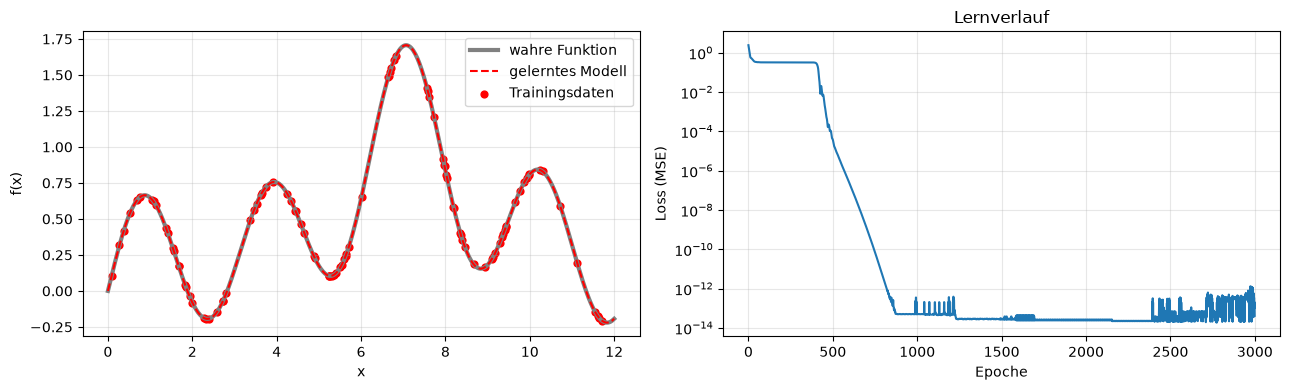

In [43]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# --- 1) Daten: N=100 Beispiele mit der "wahren" Funktion f erzeugen ---
def f(x):
    return 0.5 * np.sin(2 * x) + 0.3 * np.sin(0.7 * x) + 1.5 * np.exp(-((x - 7) ** 2) / 4)

N = 100
rng = np.random.default_rng(seed=42)
x_samples = rng.uniform(0, 12, size=N)
df = pd.DataFrame({"x": x_samples, "f(x)": f(x_samples)})
display(df.head())

# --- 2) Modell: gleiche Struktur wie f, Parameter aber zufällig initialisiert ---
class Funktion(nn.Module):
    """f(x) = a1*sin(w1*x) + a2*sin(w2*x) + a3*exp(-(x-mu)^2 / s)"""

    def __init__(self):
        super().__init__()
        # Zufällige Startwerte in plausiblen Bereichen

        initrange = "far_away_from_optimal"
        if initrange == "near_to_optimal":
            self.a1 = nn.Parameter(torch.rand(()) * 2)
            self.w1 = nn.Parameter(1.5 + torch.rand(()))
            self.a2 = nn.Parameter(torch.rand(()) * 2)
            self.w2 = nn.Parameter(0.4 + torch.rand(()) * 0.8)
            self.a3 = nn.Parameter(torch.rand(()) * 2)
            self.mu = nn.Parameter(5 + torch.rand(()) * 4)
            self.s  = nn.Parameter(2 + torch.rand(()) * 4)
        else:
            c = 2.0
            self.a1 = nn.Parameter(torch.rand(()) * c)
            self.w1 = nn.Parameter(torch.rand(()) * c)
            self.a2 = nn.Parameter(torch.rand(()) * c)
            self.w2 = nn.Parameter(torch.rand(()) * c)
            self.a3 = nn.Parameter(torch.rand(()) * c)
            self.mu = nn.Parameter(torch.rand(()) * c)
            self.s  = nn.Parameter(torch.rand(()) * c)

    def forward(self, x):
        s = self.s.abs() + 1e-2
        zweig_a = self.a1 * torch.sin(self.w1 * x)
        zweig_b = self.a2 * torch.sin(self.w2 * x)
        zweig_c = self.a3 * torch.exp(-((x - self.mu) ** 2) / s)
        return zweig_a + zweig_b + zweig_c

torch.manual_seed(1)   # anderer Seed -> andere Startwerte (manche bleiben in lokalen Minima hängen)
modell = Funktion()
start = {name: p.item() for name, p in modell.named_parameters()}

# --- 3) Training ---
x_train = torch.tensor(df["x"].values, dtype=torch.float32)
y_train = torch.tensor(df["f(x)"].values, dtype=torch.float32)

optimizer = torch.optim.Adam(modell.parameters(), lr=0.05)
verlauf = []
for epoche in range(3000):
    optimizer.zero_grad()                              # alte Gradienten löschen
    y_pred = modell(x_train)                           # Forward: Berechnungsgraph aufbauen
    loss = ((y_pred - y_train) ** 2).mean()            # Fehler (MSE)
    loss.backward()                                    # Backward: Gradienten durch den Graphen
    optimizer.step()                                   # Parameter anpassen
    verlauf.append(loss.item())
    if epoche % 500 == 0:
        print(f"Epoche {epoche:4d}  Loss = {loss.item():.6f}")
print(f"Endloss: {verlauf[-1]:.2e}")

# --- 4) Ergebnis ---
wahr = dict(a1=0.5, w1=2.0, a2=0.3, w2=0.7, a3=1.5, mu=7.0, s=4.0)
vergleich = pd.DataFrame({
    "wahr": wahr,
    "Start (zufällig)": start,
    "gelernt": {name: p.item() for name, p in modell.named_parameters()},
}).round(3)
display(vergleich)

x_plot = np.linspace(0, 12, 500)
with torch.no_grad():
    y_modell = modell(torch.tensor(x_plot, dtype=torch.float32)).numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(x_plot, f(x_plot), color="gray", lw=3, label="wahre Funktion")
ax1.plot(x_plot, y_modell, "r--", label="gelerntes Modell")
ax1.scatter(df["x"], df["f(x)"], s=24, color="red", alpha=1.0, label="Trainingsdaten")
ax1.set_xlabel("x"); ax1.set_ylabel("f(x)"); ax1.legend(); ax1.grid(alpha=0.3)
ax2.semilogy(verlauf)
ax2.set_xlabel("Epoche"); ax2.set_ylabel("Loss (MSE)"); ax2.set_title("Lernverlauf"); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
df

,x,f(x)
0,9.287473,0.334797
1,5.266541,0.104692
2,10.303175,0.829739
3,8.368416,0.387113
4,1.130128,0.599403
5,11.707468,-0.206016
6,9.133676,0.238736
7,9.432772,0.443889
8,1.537364,0.298313
9,5.404631,0.122968


In [25]:
torch.rand(())

tensor(0.7544)

In [34]:
w1 = np.nan

In [35]:
w1 * 10

nan

In [36]:
w1 + 20

nan